In [8]:
import matplotlib.pyplot as plt
import pandas as pd

from testrig_control_with_sofirpy.experimental_run import ExperimentalRun

# from sofirpy import plot_results
import test_rig_control_model.common as co
from testrig_control_with_sofirpy.utils import get_run_names_from_file

import scipy.stats as st
import numpy as np

plt.style.use("../FST.mplstyle")
plt.rcParams["font.size"] = 13
plt.rcParams.update({"text.usetex": True, "font.family": "Helvetica"})


In [9]:
sim_df_c_35_75 = pd.read_hdf("../data/constant_operating_point_3536_75.hdf5", "df")
sim_df_c_35_50 = pd.read_hdf("../data/constant_operating_point_3536_50.hdf5", "df")
sim_df_c_41_75 = pd.read_hdf("../data/constant_operating_point_4167_75.hdf5", "df")
sim_df_p_35_41 = pd.read_hdf("../data/pump_speedup_3536_to_41.hdf5", "df")
sim_df_v_25s = pd.read_hdf("../data/valve_closure_3536_75_to_50.hdf5", "df")
sim_df_v_5s = pd.read_hdf("../data/valve_closure_3536_75_to_50_5s.hdf5", "df")

In [10]:
def get_exp_results(file_name, run_index):
    run_names = get_run_names_from_file(co.DATA_DIR / file_name)
    usable_runs = run_names
    run = ExperimentalRun.from_hdf5(usable_runs[run_index], co.DATA_DIR / file_name)
    return run.time_series


exp_df_c_35_75 = get_exp_results("system_1_constant_operating_point_3536_75.hdf5", 1)
exp_df_c_35_50 = get_exp_results(
    "subsystem_1_step_response_operating_point_2kPa.hdf5", 11
)
exp_df_c_41_75 = get_exp_results("system_1_constant_operating_point_4167_75.hdf5", 0)
exp_df_p_35_41 = get_exp_results("system_1_pump_speed_up_3536_to_4167.hdf5", 1)
exp_df_v_25s = get_exp_results("system_1_valve_closure_75_to_50_25s.hdf5", 0)
exp_df_v_5s = get_exp_results("system_1_valve_closure_75_to_50_5s.hdf5", 0)

HDF5ToRun::WARNING::The following dependencies were installed when storing the run in the hdf5 and are not installed in the current environment:
future, mypy-extensions
HDF5ToRun::WARNING::The following dependencies have a different version: tzdata, click, nidaqmx, pyzmq, msgpack, tzlocal, types-tqdm, pyparsing, statsmodels, python-gitlab, blosc2, typing_extensions, certifi, contourpy, MarkupSafe, requests, OMPython, urllib3, ndindex, hightime, ruptures, types-pytz, identify, lxml, filelock, joblib, pywin32, scipy, packaging, platformdirs, lark, pytest-cov, pandas, tables, pluggy, attrs, Jinja2, idna, pip, fonttools, PyYAML, pytest, pre_commit, kiwisolver, cloudpickle, distlib, scikit-learn, coverage, ruff, iniconfig, numexpr, FMPy, mypy, virtualenv, pytz, psutil, numpy, matplotlib, pandas-stubs, charset-normalizer, six, pillow, patsy, uncertainties, h5py
HDF5ToRun::INFO::'2026-Feb-04 10:02:57' successfully loaded from 'C:\Users\Lestakova\Documents\test-rig-control-model\data\system_1_

In [11]:
## constants
# gravitational constant
g = 9.81  # m/s^2
# wave speed
a = 1.0e3  # m/s
# density
rho = 998.2  # kg/m^3
# dynamic viscosity
mu = 1.002e-3  # Ns/m^2

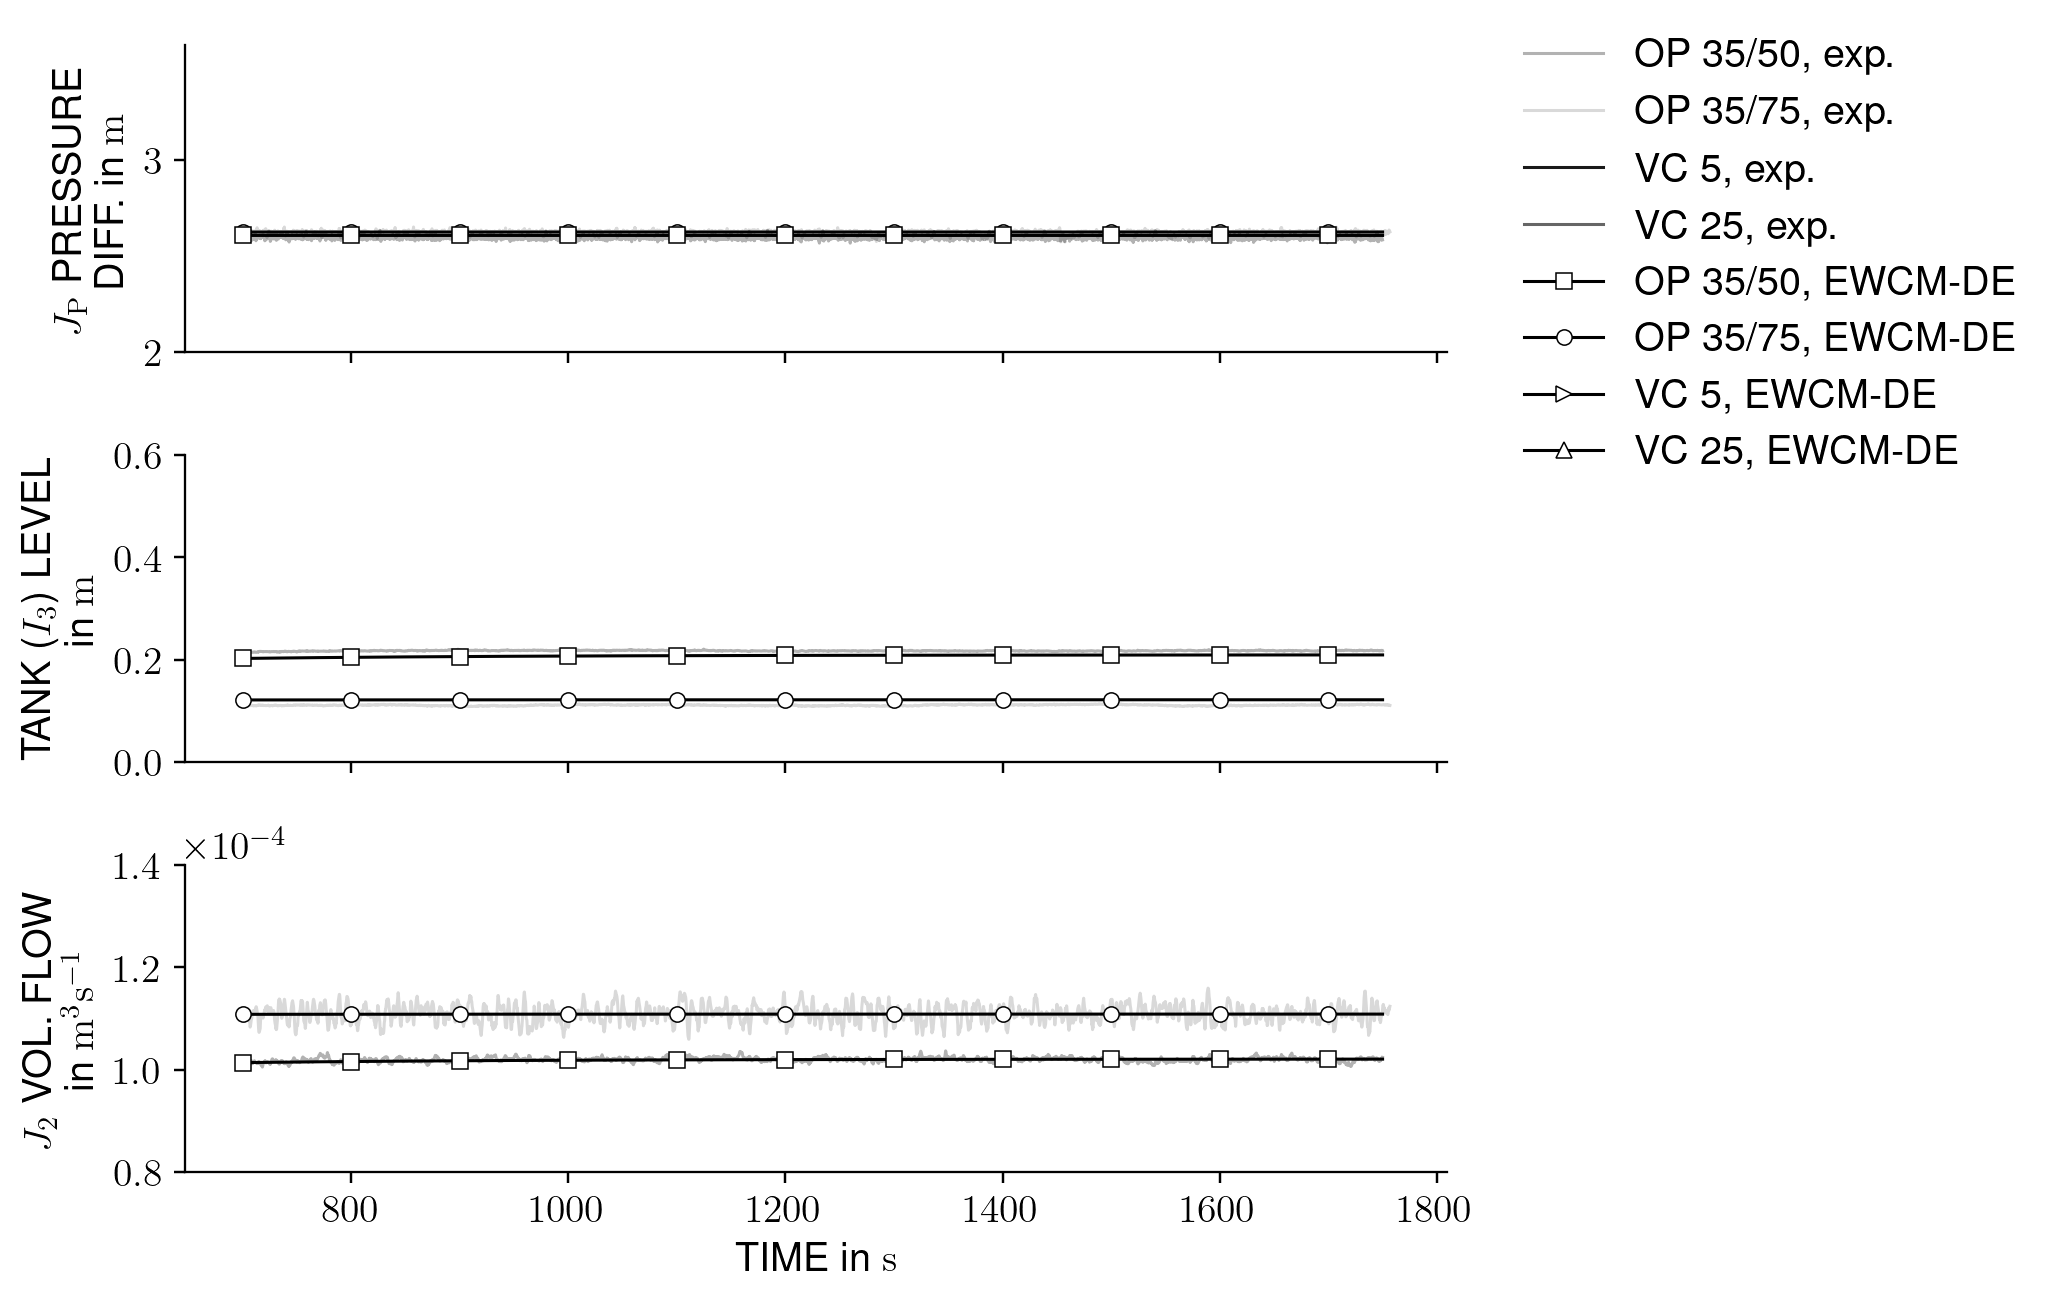

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(7, 6), sharex=True)

plot_start_time = 700 * 100
plot_end_time = 1750 * 100

time_conv = len(exp_df_c_35_50["time"]) / (1800 * 100)

plot_start_time_exp = int(time_conv * plot_start_time)
plot_end_time_exp = int(time_conv * plot_end_time)

alpha = 0.3
linewidth = 1
markevery = 10000

marker_style = dict(
    markerfacecolor="w", markeredgecolor="k", markeredgewidth=0.5, markersize=5
)

## $J_\mathrm{P}$ PRESSURE
axs[0].plot(
    exp_df_c_35_75["time"][plot_start_time_exp:plot_end_time_exp],
    exp_df_c_35_75["test_rig.pump_1_pressure"][plot_start_time_exp:plot_end_time_exp]
    / (rho * g),
    label="c 35/75, exp",
    c="k",
    alpha=alpha / 2,
    linewidth=linewidth,
)


axs[0].plot(
    exp_df_c_35_50["time"][plot_start_time_exp:plot_end_time_exp],
    exp_df_c_35_50["test_rig.pump_1_pressure"][plot_start_time_exp:plot_end_time_exp]
    / (rho * g),
    label="c 35/50, exp",
    c="k",
    alpha=alpha,
    linewidth=linewidth,
)

axs[0].plot(
    exp_df_v_5s["time"][plot_start_time_exp:plot_end_time_exp],
    exp_df_v_5s["test_rig.pump_1_pressure"][plot_start_time_exp:plot_end_time_exp]
    / (rho * g),
    label="valve closure 5s, exp",
    c="k",
    alpha=alpha * 3,
    linewidth=linewidth,
)

axs[0].plot(
    exp_df_v_25s["time"][plot_start_time_exp:plot_end_time_exp],
    exp_df_v_25s["test_rig.pump_1_pressure"][plot_start_time_exp:plot_end_time_exp]
    / (rho * g),
    label="valve closure 25s, exp",
    c="k",
    alpha=alpha * 2,
    linewidth=linewidth,
)

axs[0].plot(
    sim_df_c_35_75["time"][plot_start_time:plot_end_time],
    sim_df_c_35_75["h_I_pump_outlet"][plot_start_time:plot_end_time]
    - sim_df_c_35_75["h_I_pump_inlet"][plot_start_time:plot_end_time],
    label="c 35/75, EWCM-DE",
    c="k",
    marker="o",
    markevery=markevery,
    linewidth=linewidth,
    **marker_style,
)
axs[0].plot(
    sim_df_c_35_50["time"][plot_start_time:plot_end_time],
    sim_df_c_35_50["h_I_pump_outlet"][plot_start_time:plot_end_time]
    - sim_df_c_35_50["h_I_pump_inlet"][plot_start_time:plot_end_time],
    label="c 35/50, EWCM-DE",
    c="k",
    marker="s",
    markevery=markevery,
    linewidth=linewidth,
    **marker_style,
)

axs[0].plot(
    sim_df_v_5s["time"][plot_start_time:plot_end_time],
    sim_df_v_5s["h_I_pump_outlet"][plot_start_time:plot_end_time]
    - sim_df_v_5s["h_I_pump_inlet"][plot_start_time:plot_end_time],
    label="VC 5s, EWCM-DE",
    c="k",
    marker=">",
    markevery=markevery,
    linewidth=linewidth,
    **marker_style,
)

axs[0].plot(
    sim_df_v_25s["time"][plot_start_time:plot_end_time],
    sim_df_v_25s["h_I_pump_outlet"][plot_start_time:plot_end_time]
    - sim_df_v_25s["h_I_pump_inlet"][plot_start_time:plot_end_time],
    label="valve closure 25s, EWCM-DE",
    c="k",
    marker="^",
    markevery=markevery,
    linewidth=linewidth,
    **marker_style,
)


## TANK ($I_\mathrm{3}$) LEVEL
(l1,) = axs[1].plot(
    exp_df_c_35_75["time"][plot_start_time_exp:plot_end_time_exp],
    exp_df_c_35_75["test_rig.tank_1_pressure"][plot_start_time_exp:plot_end_time_exp]
    / (rho * g),
    label="OP 35/75, exp.",
    c="k",
    alpha=alpha / 2,
    linewidth=linewidth,
)


(l2,) = axs[1].plot(
    exp_df_c_35_50["time"][plot_start_time_exp:plot_end_time_exp],
    exp_df_c_35_50["test_rig.tank_1_pressure"][plot_start_time_exp:plot_end_time_exp]
    / (rho * g),
    label="OP 35/50, exp.",
    c="k",
    alpha=alpha,
    linewidth=linewidth,
)

(l33,) = axs[1].plot(
    exp_df_v_5s["time"][plot_start_time_exp:plot_end_time_exp],
    exp_df_v_5s["test_rig.tank_1_pressure"][plot_start_time_exp:plot_end_time_exp]
    / (rho * g),
    label="VC 5, exp.",
    c="k",
    alpha=alpha * 3,
    linewidth=linewidth,
    zorder=100,
)

(l3,) = axs[1].plot(
    exp_df_v_25s["time"][plot_start_time_exp:plot_end_time_exp],
    exp_df_v_25s["test_rig.tank_1_pressure"][plot_start_time_exp:plot_end_time_exp]
    / (rho * g),
    label="VC 25, exp.",
    c="k",
    alpha=alpha * 2,
    linewidth=linewidth,
)

(l4,) = axs[1].plot(
    sim_df_c_35_75["time"][plot_start_time:plot_end_time],
    sim_df_c_35_75["h_I_tank_outlet"][plot_start_time:plot_end_time] - 1.2,
    label="OP 35/75, EWCM-DE",
    c="k",
    marker="o",
    markevery=markevery,
    linewidth=linewidth,
    **marker_style,
)
(l5,) = axs[1].plot(
    sim_df_c_35_50["time"][plot_start_time:plot_end_time],
    sim_df_c_35_50["h_I_tank_outlet"][plot_start_time:plot_end_time] - 1.2,
    label="OP 35/50, EWCM-DE",
    c="k",
    marker="s",
    markevery=markevery,
    linewidth=linewidth,
    **marker_style,
)

(l66,) = axs[1].plot(
    sim_df_v_5s["time"][plot_start_time:plot_end_time],
    sim_df_v_5s["h_I_tank_outlet"][plot_start_time:plot_end_time] - 1.2,
    label="VC 5, EWCM-DE",
    c="k",
    marker=">",
    markevery=markevery,
    linewidth=linewidth,
    **marker_style,
)

(l6,) = axs[1].plot(
    sim_df_v_25s["time"][plot_start_time:plot_end_time],
    sim_df_v_25s["h_I_tank_outlet"][plot_start_time:plot_end_time] - 1.2,
    label="VC 25, EWCM-DE",
    c="k",
    marker="^",
    markevery=markevery,
    linewidth=linewidth,
    **marker_style,
)

## CONSUMER FLOW

axs[2].plot(
    exp_df_c_35_75["time"][plot_start_time_exp:plot_end_time_exp],
    exp_df_c_35_75["test_rig.consumer_1_volume_flow"][
        plot_start_time_exp:plot_end_time_exp
    ],
    label="c 35/75, exp",
    c="k",
    alpha=alpha / 2,
    linewidth=linewidth,
)


axs[2].plot(
    exp_df_c_35_50["time"][plot_start_time_exp:plot_end_time_exp],
    exp_df_c_35_50["test_rig.consumer_1_volume_flow"][
        plot_start_time_exp:plot_end_time_exp
    ],
    label="c 35/50, exp",
    c="k",
    alpha=alpha,
    linewidth=linewidth,
)

axs[2].plot(
    exp_df_v_5s["time"][plot_start_time_exp:plot_end_time_exp],
    exp_df_v_5s["test_rig.consumer_1_volume_flow"][
        plot_start_time_exp:plot_end_time_exp
    ],
    label="vc 5s, exp",
    c="k",
    alpha=alpha * 3,
    linewidth=linewidth,
)

axs[2].plot(
    exp_df_v_25s["time"][plot_start_time_exp:plot_end_time_exp],
    exp_df_v_25s["test_rig.consumer_1_volume_flow"][
        plot_start_time_exp:plot_end_time_exp
    ],
    label="vc 25s, exp",
    c="k",
    alpha=alpha * 2,
    linewidth=linewidth,
)

axs[2].plot(
    sim_df_c_35_75["time"][plot_start_time:plot_end_time],
    sim_df_c_35_75["q_p_tank_outlet_pipe"][plot_start_time:plot_end_time],
    label="c 35/75, EWCM-DE",
    c="k",
    marker="o",
    markevery=markevery,
    linewidth=linewidth,
    **marker_style,
)
axs[2].plot(
    sim_df_c_35_50["time"][plot_start_time:plot_end_time],
    sim_df_c_35_50["q_p_tank_outlet_pipe"][plot_start_time:plot_end_time],
    label="c 35/50, EWCM-DE",
    c="k",
    marker="s",
    markevery=markevery,
    linewidth=linewidth,
    **marker_style,
)

axs[2].plot(
    sim_df_v_5s["time"][plot_start_time:plot_end_time],
    sim_df_v_5s["q_p_tank_outlet_pipe"][plot_start_time:plot_end_time],
    label="vc 5s, EWCM-DE",
    c="k",
    marker=">",
    markevery=markevery,
    linewidth=linewidth,
    **marker_style,
)

axs[2].plot(
    sim_df_v_25s["time"][plot_start_time:plot_end_time],
    sim_df_v_25s["q_p_tank_outlet_pipe"][plot_start_time:plot_end_time],
    label="vc 25s, EWCM-DE",
    c="k",
    marker="^",
    markevery=markevery,
    linewidth=linewidth,
    **marker_style,
)


##  axs[0].plot(
##      exp_df_c_41_75["time"],
##      exp_df_c_41_75["test_rig.pump_1_pressure"] / (rho * g),
##      label="c 41/75, exp",
##      c="lightgrey",
##      alpha=alpha,
##  )
##  axs[0].plot(
##      sim_df_c_41_75["time"],
##      sim_df_c_41_75["h_I_pump_outlet"] - sim_df_c_41_75["h_I_pump_inlet"],
##      label="c 41/75, EWCM-DE",
##      c="k",
##  )

axs[0].set_ylim(2, 3.6)
axs[1].set_ylim(0, 0.6)
axs[2].set_ylim(0.00008, 0.00014)
# axs[0].set_xlabel("TIME in s")
axs[0].set_ylabel("$J_\mathrm{P}$ PRESSURE \n DIFF.  in $\mathrm{m}$")

# axs[1].set_xlabel("TIME in s")
axs[1].set_ylabel("TANK ($I_\mathrm{3}$) LEVEL \nin $\mathrm{m}$")

axs[2].set_xlabel("TIME in $\mathrm{s}$")
axs[2].set_ylabel("$J_2$ VOL. FLOW \nin $\mathrm{m}^3\mathrm{s}^{-1}$")

axs[2].ticklabel_format(scilimits=(1e-3, 1e5))

fig.legend(
    handles=[l2, l1, l33, l3, l5, l4, l66, l6],
    bbox_to_anchor=(0.98, 1),
    loc="upper left",
)
fig.tight_layout()

# fig.savefig("fig_vc.pdf", bbox_inches="tight")
fig.savefig("fig_vc.svg", bbox_inches="tight")
fig.savefig("fig_vc.png", bbox_inches="tight")

In [13]:
exp_df_v_25s.columns

Index(['time', 'test_rig.pump_1_pressure', 'test_rig.pump_2_pressure',
       'test_rig.control_valve_pressure', 'test_rig.tank_1_pressure',
       'test_rig.tank_2_pressure', 'test_rig.leakage_volume_flow',
       'test_rig.consumer_1_volume_flow', 'test_rig.consumer_2_volume_flow',
       'test_rig.pump_1_power', 'test_rig.pump_2_power',
       'test_rig.fluid_temperature', 'test_rig.leakage_valve_opening',
       'test_rig.support_valve_opening', 'test_rig.consumer_1_valve_opening',
       'test_rig.consumer_2_valve_opening', 'test_rig.control_valve_1_opening',
       'test_rig.control_valve_2_opening', 'test_rig.ball_valve_1_opening',
       'test_rig.ball_valve_2_opening', 'pump_1.output',
       'consumer_valve_1.output'],
      dtype='object')

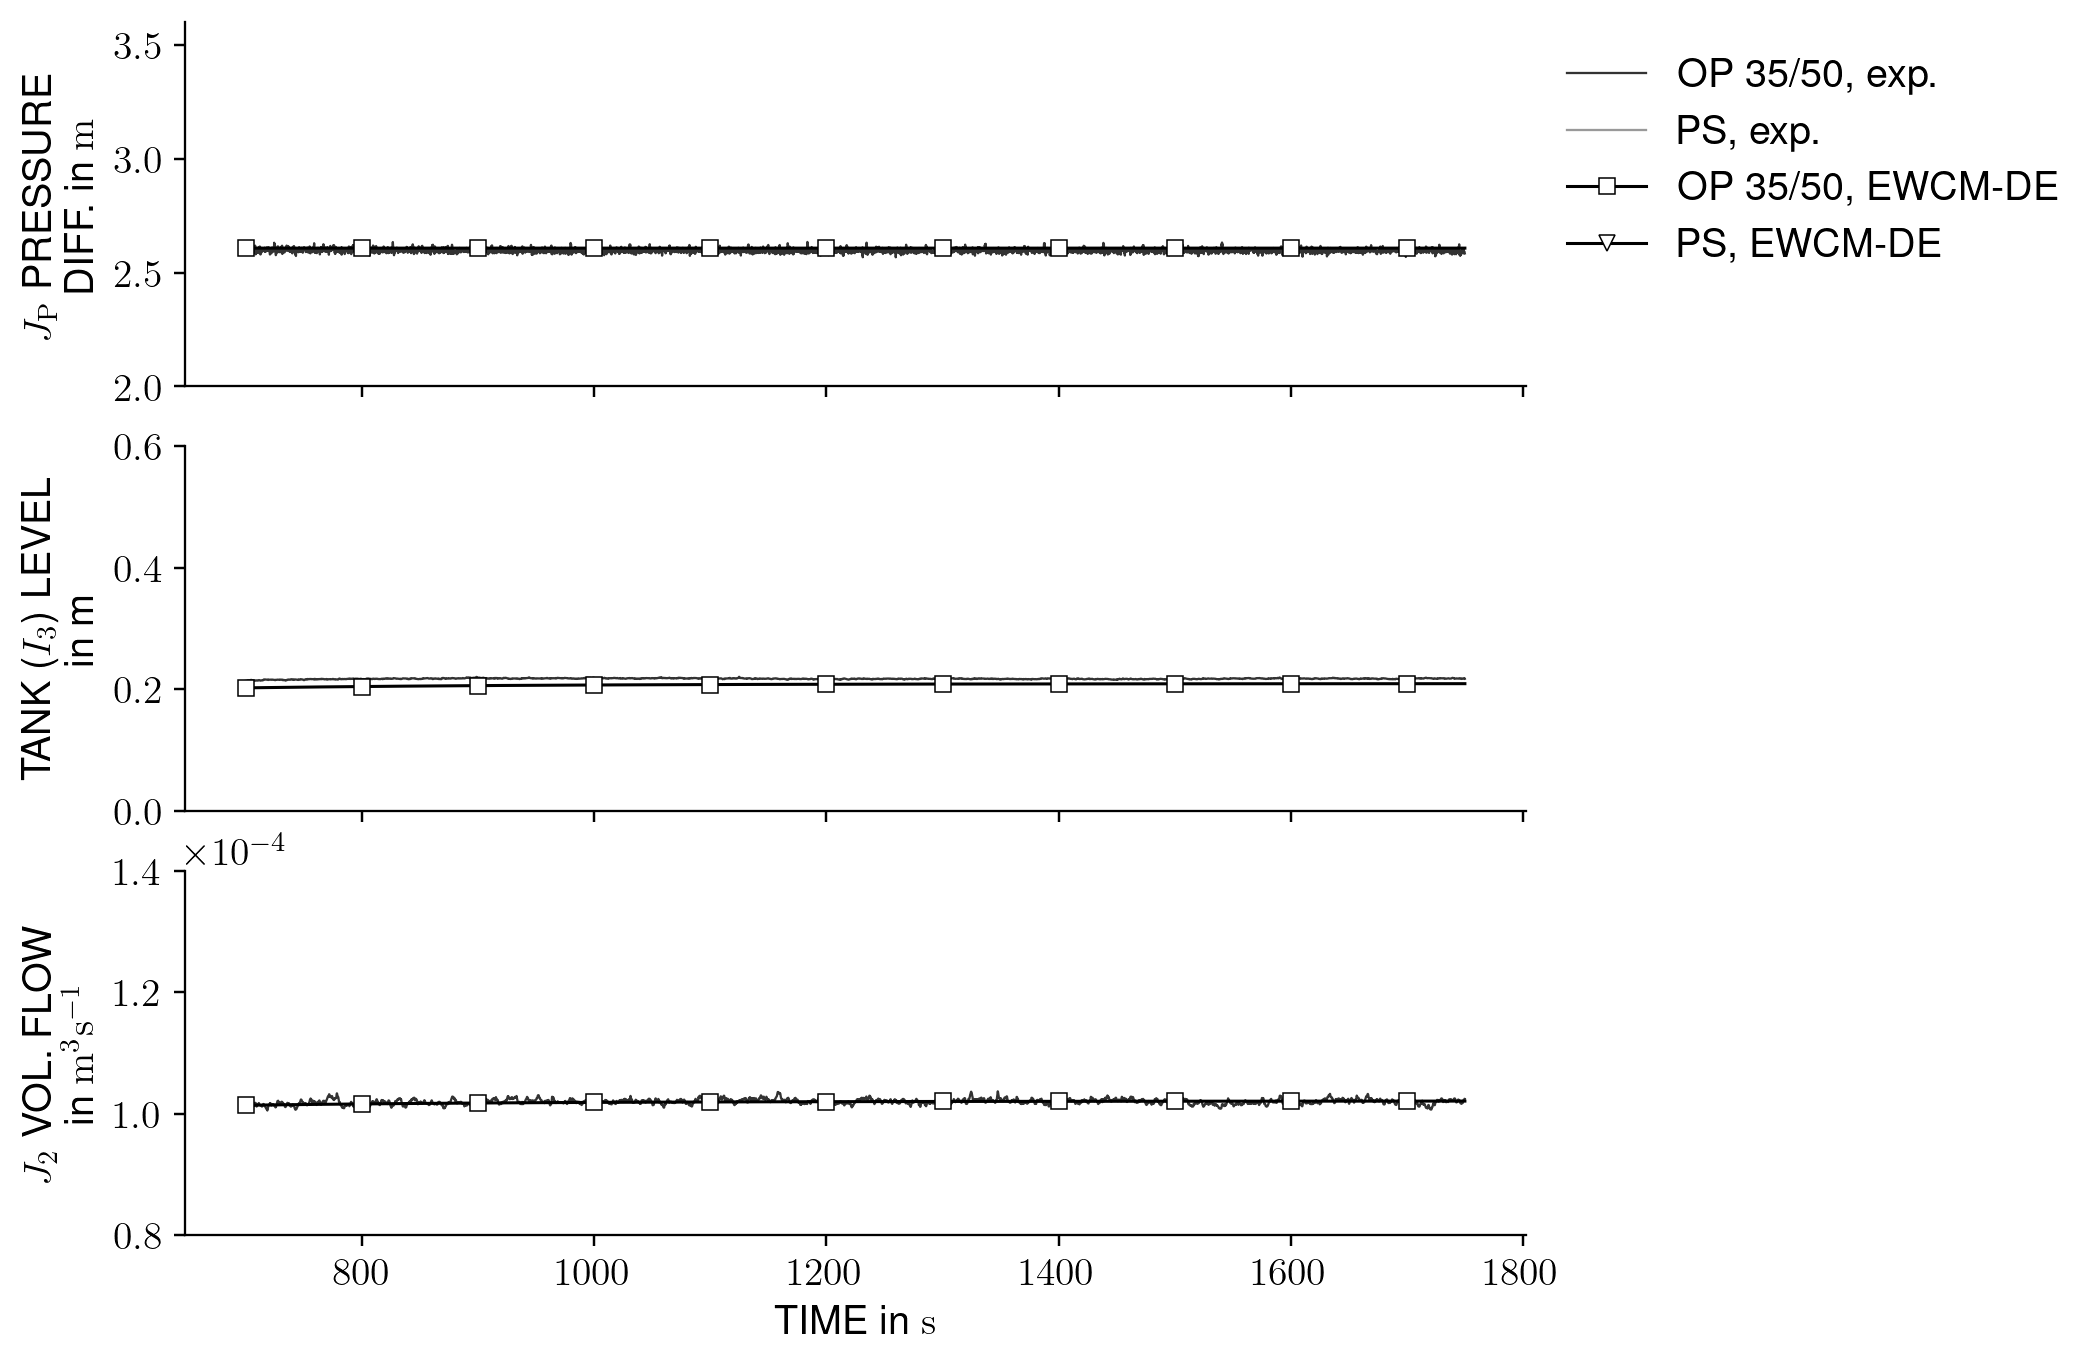

In [ ]:
fig, axs = plt.subplots(3, 1, figsize=(7, 6), sharex=True)

plot_start_time = 700 * 100
plot_end_time = 1750 * 100

time_conv = len(exp_df_c_35_50["time"]) / (1800 * 100)

plot_start_time_exp = int(time_conv * plot_start_time)
plot_end_time_exp = int(time_conv * plot_end_time)

alpha = 0.8

## $J_\mathrm{P}$ PRESSURE
(l1,) = axs[0].plot(
    exp_df_c_35_50["time"][plot_start_time_exp:plot_end_time_exp],
    exp_df_c_35_50["test_rig.pump_1_pressure"][plot_start_time_exp:plot_end_time_exp]
    / (rho * g),
    label=r"OP 35/50, exp.",
    c="k",
    alpha=alpha,
)
(l2,) = axs[0].plot(
    sim_df_c_35_50["time"][plot_start_time:plot_end_time],
    sim_df_c_35_50["h_I_pump_outlet"][plot_start_time:plot_end_time]
    - sim_df_c_35_50["h_I_pump_inlet"][plot_start_time:plot_end_time],
    label=r"OP 35/50, EWCM-DE",
    c="k",
    marker="s",
    markevery=markevery,
    linewidth=linewidth,
    **marker_style,
)
## axs[0].plot(
##     exp_df_c_41_75["time"],
##     exp_df_c_41_75["test_rig.pump_1_pressure"] / (rho * g),
##     label="c 41/75, exp",
##     c="lightgrey",
##     alpha=alpha,
## )


## axs[0].plot(
##     sim_df_c_41_75["time"],
##     sim_df_c_41_75["h_I_pump_outlet"] - sim_df_c_41_75["h_I_pump_inlet"],
##     label="c 41/75, EWCM-DE",
##     c="k",
## )#


(l3,) = axs[0].plot(
    exp_df_p_35_41["time"][plot_start_time_exp:plot_end_time_exp],
    exp_df_p_35_41["test_rig.pump_1_pressure"][plot_start_time_exp:plot_end_time_exp]
    / (rho * g),
    label=r"PS, exp.",
    c="k",
    alpha=alpha / 2,
)

(l4,) = axs[0].plot(
    sim_df_p_35_41["time"][plot_start_time:plot_end_time],
    sim_df_p_35_41["h_I_pump_outlet"][plot_start_time:plot_end_time]
    - sim_df_p_35_41["h_I_pump_inlet"][plot_start_time:plot_end_time],
    label=r"PS, EWCM-DE",
    c="k",
    marker="v",
    markevery=markevery,
    linewidth=linewidth,
    **marker_style,
)
axs[0].set_ylim(2.56, 2.66)

## TANK ($I_\mathrm{3}$) LEVEL
axs[1].plot(
    exp_df_c_35_50["time"][plot_start_time_exp:plot_end_time_exp],
    exp_df_c_35_50["test_rig.tank_1_pressure"][plot_start_time_exp:plot_end_time_exp]
    / (rho * g),
    label="c 35/50, exp",
    c="k",
    alpha=alpha,
)


## axs[1].plot(
##     exp_df_c_41_75["time"],
##     exp_df_c_41_75["test_rig.tank_1_pressure"] / (rho * g),
##     label="c 41/75, exp",
##     c="lightgrey",
##     alpha=alpha,
## )

## axs[1].plot(
##     sim_df_c_41_75["time"],
##     sim_df_c_41_75["h_I_tank_outlet"] - 1.2,
##     label="c 41/75, EWCM-DE",
##     c="k",
## )
axs[1].plot(
    sim_df_c_35_50["time"][plot_start_time:plot_end_time],
    sim_df_c_35_50["h_I_tank_outlet"][plot_start_time:plot_end_time] - 1.2,
    label="c 35/50, EWCM-DE",
    c="k",
    marker="s",
    markevery=markevery,
    linewidth=linewidth,
    **marker_style,
)

axs[1].plot(
    exp_df_p_35_41["time"][plot_start_time_exp:plot_end_time_exp],
    exp_df_p_35_41["test_rig.tank_1_pressure"][plot_start_time_exp:plot_end_time_exp]
    / (rho * g),
    label="PS, exp",
    c="k",
    alpha=alpha / 2,
)

axs[1].plot(
    sim_df_p_35_41["time"][plot_start_time:plot_end_time],
    sim_df_p_35_41["h_I_tank_outlet"][plot_start_time:plot_end_time] - 1.2,
    label="pump speedup, EWCM-DE",
    c="k",
    marker="v",
    markevery=markevery,
    linewidth=linewidth,
    **marker_style,
)

## CONSUMER FLOW

## axs[2].plot(
##     exp_df_c_41_75["time"],
##     exp_df_c_41_75["test_rig.consumer_1_volume_flow"],
##     label="c 41/75, exp",
##     c="lightgrey",
##     alpha=alpha,
## )


axs[2].plot(
    exp_df_c_35_50["time"][plot_start_time_exp:plot_end_time_exp],
    exp_df_c_35_50["test_rig.consumer_1_volume_flow"][
        plot_start_time_exp:plot_end_time_exp
    ],
    label="c 35/50, exp",
    c="k",
    alpha=alpha,
)

axs[2].plot(
    exp_df_p_35_41["time"][plot_start_time_exp:plot_end_time_exp],
    exp_df_p_35_41["test_rig.consumer_1_volume_flow"][
        plot_start_time_exp:plot_end_time_exp
    ],
    label="PS, exp",
    c="k",
    alpha=alpha / 2,
)


axs[2].plot(
    sim_df_c_35_50["time"][plot_start_time:plot_end_time],
    sim_df_c_35_50["q_p_tank_outlet_pipe"][plot_start_time:plot_end_time],
    label="c 35/50, EWCM-DE",
    c="k",
    marker="s",
    markevery=markevery,
    linewidth=linewidth,
    **marker_style,
)

# # axs[2].plot(
# #     sim_df_c_41_75["time"],
# #     sim_df_c_41_75["q_p_tank_outlet_pipe"],
# #     label="c 41/75, EWCM-DE",
# #     c="k",
# # )

axs[2].plot(
    sim_df_p_35_41["time"][plot_start_time:plot_end_time],
    sim_df_p_35_41["q_p_tank_outlet_pipe"][plot_start_time:plot_end_time],
    label="pump speedup, EWCM-DE",
    c="k",
    marker="v",
    markevery=markevery,
    linewidth=linewidth,
    **marker_style,
)

## axs[0].set_ylim(2, 3.8)
## axs[1].set_ylim(0.0, 0.6)
## axs[2].set_ylim(0.00007, 0.00015)
axs[0].set_ylim(2, 3.6)
axs[1].set_ylim(0, 0.6)
axs[2].set_ylim(0.00008, 0.00014)

# axs[0].set_xlabel("TIME in s")
axs[0].set_ylabel("$J_\mathrm{P}$ PRESSURE \n DIFF. in $\mathrm{m}$")

# axs[1].set_xlabel("TIME in s")
axs[1].set_ylabel("TANK ($I_\mathrm{3}$) LEVEL \nin m")

axs[2].set_xlabel("TIME in $\mathrm{s}$")
axs[2].set_ylabel("$J_2$ VOL. FLOW \nin $\mathrm{m}^3\mathrm{s}^{-1}$")

axs[2].ticklabel_format(scilimits=(1e-3, 1e5))
fig.legend(handles=[l1, l3, l2, l4], bbox_to_anchor=(0.98, 1), loc="upper left")
fig.tight_layout(pad=0)

# fig.savefig("fig_ps.pdf", bbox_inches="tight")
fig.savefig("fig_ps.svg", bbox_inches="tight")
fig.savefig("fig_ps.png", bbox_inches="tight")

In [8]:
sim_df_p_35_41.columns

Index(['q_p_pump_suction_pipe', 'q_p_tank_feeding_pipe',
       'q_p_tank_outlet_pipe', 'q_p_consumer_outlet_pipe', 'h_I_pump_inlet',
       'h_I_pump_outlet', 'h_I_tank_inlet', 'h_I_tank_outlet',
       'h_I_consumer_valve_inlet', 'h_I_consumer_valve_outlet', 'z_p_pump',
       'z_v_consumer_valve', 'time'],
      dtype='object')

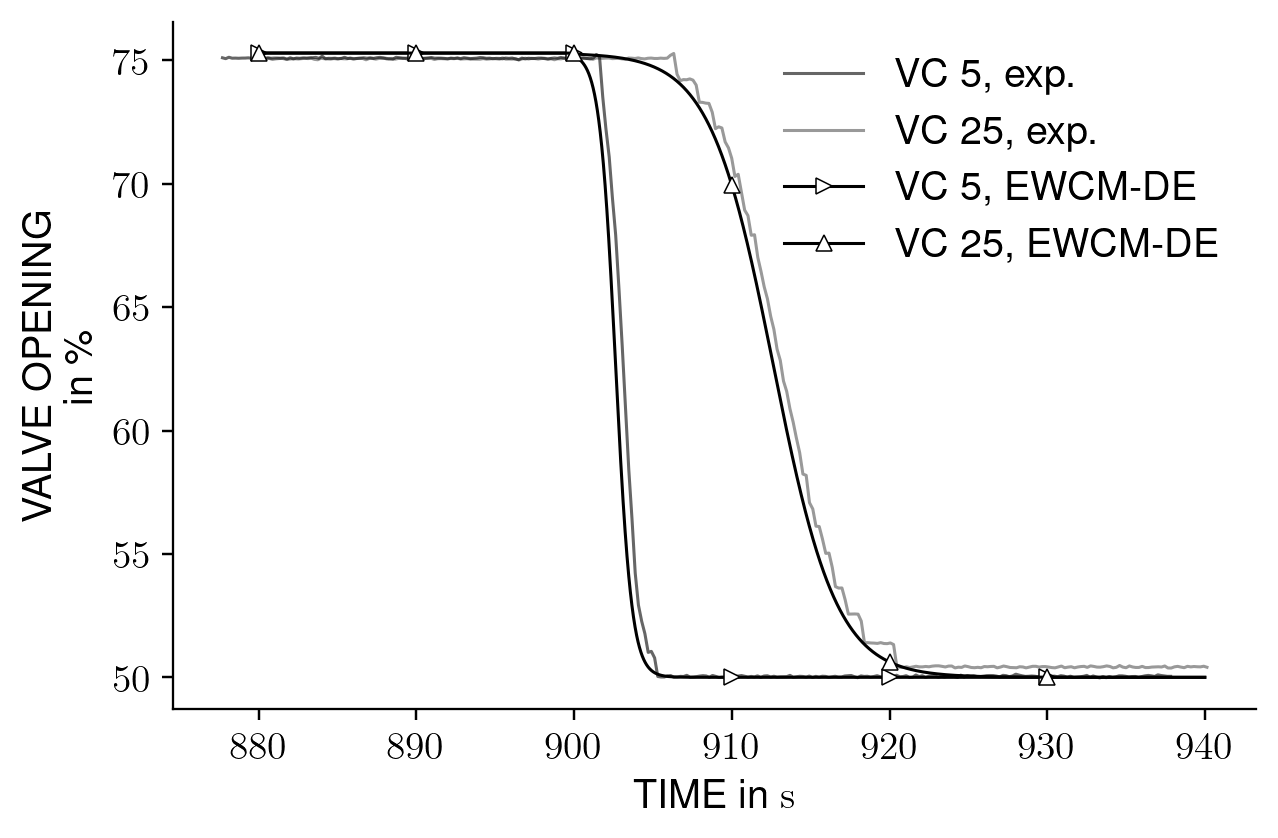

In [9]:
fig, axs = plt.subplots(1, figsize=(6, 4))


plot_start_time = 880 * 100
plot_end_time = 940 * 100

time_conv = len(exp_df_c_35_50["time"]) / (1800 * 100)

plot_start_time_exp = int(time_conv * plot_start_time)
plot_end_time_exp = int(time_conv * plot_end_time)

alpha = 0.2
linewidth = 1
markevery = 10000

marker_style = dict(
    markerfacecolor="w", markeredgecolor="k", markeredgewidth=0.5, markersize=5
)

axs.plot(
    exp_df_v_5s["time"][plot_start_time_exp - 25 : plot_end_time_exp - 25],
    exp_df_v_5s["test_rig.consumer_1_valve_opening"][
        plot_start_time_exp - 25 : plot_end_time_exp - 25
    ],
    label="VC 5, exp.",
    c="k",
    alpha=alpha * 3,
    linewidth=linewidth,
)


axs.plot(
    exp_df_v_25s["time"][plot_start_time_exp - 25 : plot_end_time_exp - 25],
    exp_df_v_25s["test_rig.consumer_1_valve_opening"][
        plot_start_time_exp - 25 : plot_end_time_exp - 25
    ],
    label="VC 25, exp.",
    c="k",
    alpha=alpha * 2,
    linewidth=linewidth,
)

axs.plot(
    sim_df_v_5s["time"][plot_start_time:plot_end_time],
    sim_df_v_5s["z_v_consumer_valve"][plot_start_time:plot_end_time] * 100,
    label="VC 5, EWCM-DE",
    c="k",
    marker=">",
    markevery=1000,
    linewidth=linewidth,
    **marker_style,
)

axs.plot(
    sim_df_v_25s["time"][plot_start_time:plot_end_time],
    sim_df_v_25s["z_v_consumer_valve"][plot_start_time:plot_end_time] * 100,
    label="VC 25, EWCM-DE",
    c="k",
    marker="^",
    markevery=1000,
    linewidth=linewidth,
    **marker_style,
)

# axs[1].plot(
#     exp_df_p_35_41["time"][plot_start_time_exp + 50 : plot_end_time_exp + 50],
#     exp_df_p_35_41["pump_1.output"][plot_start_time_exp + 50 : plot_end_time_exp + 50],
#     label="PS, exp.",
#     c="k",
#     alpha=alpha * 2,
#     linewidth=linewidth,
# )

# axs[1].plot(
#     sim_df_p_35_41["time"][plot_start_time:plot_end_time],
#     sim_df_p_35_41["z_p_pump"][plot_start_time:plot_end_time],
#     label="PS, EWCM-DE",
#     c="k",
#     marker="v",
#     markevery=1000,
#     linewidth=linewidth,
#     **marker_style,
# )


axs.set_xlabel("TIME in $\mathrm{s}$")
axs.set_ylabel("VALVE OPENING \nin \%")

# axs[1].set_xlabel("TIME in $\mathrm{s}$")
# axs[1].set_ylabel("PUMP SPEED \nin $\mathrm{s}^{-1}$")

axs.legend()
# axs[1].legend()

fig.tight_layout()
# fig.savefig("fig_dynamic_elements.pdf")
fig.savefig("fig_dynamic_elements.svg")
fig.savefig("fig_dynamic_elements.png")

In [146]:
df1 = get_exp_results("system_1_pump_speed_up_3536_to_4167.hdf5", 0)
df2 = get_exp_results("system_1_pump_speed_up_3536_to_4167.hdf5", 1)
df3 = get_exp_results("system_1_pump_speed_up_3536_to_4167.hdf5", 2)

HDF5ToRun::WARNING::The following dependencies were installed when storing the run in the hdf5 and are not installed in the current environment:
mypy-extensions, future
HDF5ToRun::WARNING::The following dependencies have a different version: patsy, statsmodels, pre_commit, requests, OMPython, ruptures, six, charset-normalizer, click, hightime, ruff, tzlocal, packaging, pytz, urllib3, matplotlib, lark, lxml, types-tqdm, tables, pywin32, MarkupSafe, types-pytz, iniconfig, uncertainties, pandas, tzdata, coverage, blosc2, typing_extensions, cloudpickle, fonttools, pyzmq, certifi, pandas-stubs, FMPy, virtualenv, identify, pyparsing, platformdirs, numexpr, pip, nidaqmx, kiwisolver, pytest, scipy, joblib, attrs, pytest-cov, psutil, mypy, msgpack, numpy, Jinja2, contourpy, h5py, scikit-learn, python-gitlab, pillow, filelock, ndindex, PyYAML, idna, distlib, pluggy
HDF5ToRun::INFO::'2026-Feb-05 11:25:54' successfully loaded from 'C:\Users\Lestakova\Documents\test-rig-control-model\data\system_1_

In [147]:
df1

,time,test_rig.pump_1_pressure,test_rig.pump_2_pressure,test_rig.control_valve_pressure,test_rig.tank_1_pressure,test_rig.tank_2_pressure,test_rig.leakage_volume_flow,test_rig.consumer_1_volume_flow,test_rig.consumer_2_volume_flow,test_rig.pump_1_power,...,test_rig.leakage_valve_opening,test_rig.support_valve_opening,test_rig.consumer_1_valve_opening,test_rig.consumer_2_valve_opening,test_rig.control_valve_1_opening,test_rig.control_valve_2_opening,test_rig.ball_valve_1_opening,test_rig.ball_valve_2_opening,pump_1.output,consumer_valve_1.output
0,0.000000,100.575526,137.579085,-130.749947,-47.760143,-82.827973,1.201199e-07,3.521775e-07,8.705822e-09,2.274816,...,-0.912034,-0.771771,-0.854006,-0.995057,0.036788,-0.862821,0.372619,0.438602,35.360000,50.0
1,0.200519,100.434216,137.572092,-131.080633,-47.804830,-83.283253,1.262137e-07,3.518802e-07,4.364577e-09,2.279803,...,-0.803544,-0.694590,-0.197269,-0.840007,0.032696,-0.778855,0.372410,0.438272,35.360000,50.0
2,0.410217,100.667768,137.080476,-132.058339,-47.760756,-83.182176,1.250350e-07,3.482329e-07,1.062644e-08,2.324993,...,-0.332064,-0.502370,5.185627,-0.101366,0.046165,-0.481211,0.372459,0.438193,35.360000,50.0
3,0.616700,100.087684,137.063024,-181.933432,-47.778327,-83.260009,1.207078e-07,3.489457e-07,5.624746e-09,2.302406,...,-0.338644,-0.475497,9.336612,-0.009306,1.007220,-0.290788,0.372527,0.438249,35.360000,50.0
4,0.818212,99.972036,137.062807,-20.245410,-47.895359,-83.195648,1.255014e-07,3.517776e-07,5.720563e-09,2.281735,...,-0.336701,-0.466824,15.852678,-0.002246,15.670725,-0.104468,0.372329,0.438289,35.360000,50.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8784,1799.351967,31045.086940,11266.433484,1415.774694,4485.635197,-87.320451,4.560363e-07,1.260032e-04,4.310855e-07,29.543081,...,-0.280735,-0.413448,50.163080,0.013835,99.596816,-0.079270,0.377641,0.439656,41.666667,50.0
8785,1799.556242,30623.224200,11326.951408,1509.279766,4487.214578,-87.437491,4.612681e-07,1.259466e-04,4.297117e-07,29.692095,...,-0.283191,-0.420836,50.142673,0.007469,99.538364,-0.069215,0.377584,0.439695,41.666667,50.0
8786,1799.756810,30505.269787,11252.264403,1570.844610,4485.905291,-87.743209,4.671897e-07,1.258558e-04,4.310796e-07,29.560565,...,-0.283174,-0.424883,50.138351,-0.028440,99.555427,-0.066570,0.377356,0.439939,41.666667,50.0
8787,1799.957146,30914.936595,11229.761970,1546.145271,4483.983694,-87.780747,4.691923e-07,1.259135e-04,4.359795e-07,29.511517,...,-0.282528,-0.438542,50.119540,0.010985,99.454013,-0.062137,0.377442,0.440075,41.666667,50.0


In [148]:
common_time = np.linspace(
    max(df1["time"].min(), df2["time"].min(), df3["time"].min()),
    min(df1["time"].max(), df2["time"].max(), df3["time"].max()),
    8000,
)

x1 = np.interp(common_time, df1["time"], df1["test_rig.pump_1_pressure"])
x2 = np.interp(common_time, df2["time"], df2["test_rig.pump_1_pressure"])
x3 = np.interp(common_time, df3["time"], df3["test_rig.pump_1_pressure"])

data = np.vstack([x1, x2, x3])

In [149]:
from scipy.signal import savgol_filter

window = 61  # must be odd
poly_order = 3

data_smooth = (
    data  # np.array([savgol_filter(signal, window, poly_order) for signal in data])
)

In [150]:
std = np.std(data_smooth, axis=0, ddof=1)
mean = np.mean(data_smooth, axis=0)
sem = std / np.sqrt(3)

In [151]:
mean

array([  102.19743168,   102.14485181,   102.08977125, ...,
       30430.0721562 , 30412.54128911, 30426.84851441], shape=(8000,))

In [152]:
t_val = st.t.ppf(0.975, df=2)

ci_lower = mean - t_val * sem
ci_upper = mean + t_val * sem

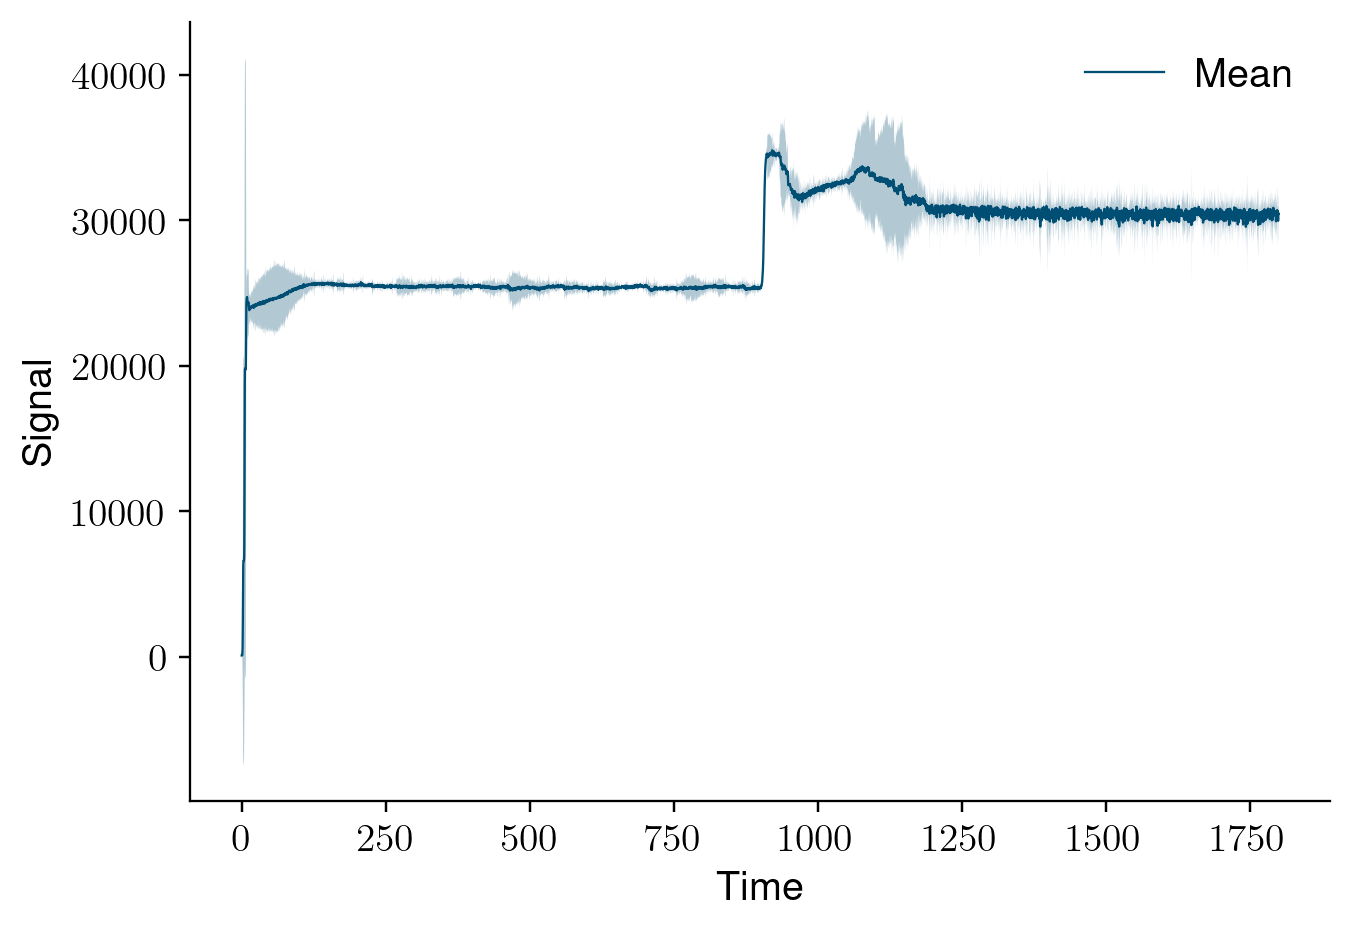

In [153]:
plt.plot(common_time, mean, label="Mean")
plt.fill_between(common_time, ci_lower, ci_upper, alpha=0.3)
plt.xlabel("Time")
plt.ylabel("Signal")
plt.legend()